In [32]:
import os
import time
import warnings

# Data manipulation and analysis
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from skimage.measure import EllipseModel

# Astropy modules
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.stats import sigma_clip
from astropy.visualization import simple_norm
from astropy.wcs import WCS

# Matplotlib for plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Ellipse

# Scipy and related modules
import scipy.sparse as sp
from scipy.ndimage import gaussian_filter
from scipy.signal import find_peaks, peak_prominences

# Spectral cube handling
from spectral_cube import SpectralCube as sc

# Progress bar
from tqdm.notebook import trange

# Additional libraries
from kneed import KneeLocator

# Multithreading
from joblib import Parallel, delayed

np.seterr(divide="ignore", invalid="ignore")
np.set_printoptions(precision=10, suppress=True)
plt.rcParams.update({'figure.max_open_warning': 0, 'font.size': 12})
delta_min = 1e-12

%matplotlib widget

In [33]:
# Define the source and target cube patterns
crafts_pattern = "./CRAFTS_RA{ra}_DEC-13_2_corrected_{sign}.fits"
hi4pi_pattern = "./HI4PI/HI4PI_RA{ra}_DEC-13_2_reproj_{sign}.fits"
output_pattern = "./Figures/CRAFTS_RA{ra}_DEC-13_2_{sign}_moment{m}.fits"
catalog_pattern = "./Catalogs/CRAFTS_RA{ra}_DEC-13_2_corrected_{sign}.csv"

# Define RA ranges and signs
ra_ranges = ["60_80", "80_100", "100_120", "120_140"]
signs = ["+", "-"]
moments = [0, 1, 2]

ra = ra_ranges[1]
sign = signs[0]

crafts_file = crafts_pattern.format(ra=ra, sign=sign)
hi4pi_file = hi4pi_pattern.format(ra=ra, sign=sign)
catalog_file = catalog_pattern.format(ra=ra, sign=sign)
output_file = []
for m in moments:
    output_file.append(output_pattern.format(ra=ra, sign=sign, m=m))

In [34]:
# CRAFTS cube
cube = sc.read(crafts_file).with_spectral_unit(u.km / u.s)
data = cube.unmasked_data[:, :, :].value
nan_count = np.isnan(data).sum()
print("NaN count:", nan_count)

hdr = cube.header
wcs = WCS(hdr)
pixel_to_deg = hdr["CDELT2"]

# data mask
# data[:,:,0:201] = np.nan

MEDIAN = np.nanmedian(data)
STD = np.nanstd(data)
print("Mean:", MEDIAN)
print("Std:", STD)

delta_v = np.float64(hdr["CDELT3"])  # velocity resolution in km/s
print("delta_v =", delta_v, "km/s")

velocities = cube.spectral_axis.value
print(cube)

# Uncomment the following lines if you want to average every two slices

# stack = data.shape[0]
# for i in range(0, stack, 2):
#     if i // 2 < stack // 2:
#         data[i // 2] = (data[i] + data[i + 1]) / 2
#
# data = data[: stack // 2]


NaN count: 0
Mean: 0.0072732717
Std: 0.10712969
delta_v = -0.201283594733 km/s
SpectralCube with shape=(994, 600, 800) and unit=K:
 n_x:    800  type_x: RA---CAR  unit_x: deg    range:    80.012500 deg:   99.987500 deg
 n_y:    600  type_y: DEC--CAR  unit_y: deg    range:   -12.987500 deg:    1.987500 deg
 n_s:    994  type_s: VRAD      unit_s: km / s  range:      114.056 km / s:     313.930 km / s


In [35]:
# HI4PI cube

hi4pi_cube = sc.read(hi4pi_file)
hidpi_data = hi4pi_cube.unmasked_data[:, :, :].value
hi4pi_cube

SpectralCube with shape=(994, 600, 800) and unit=K:
 n_x:    800  type_x: RA---CAR  unit_x: deg    range:    80.012500 deg:   99.987500 deg
 n_y:    600  type_y: DEC--CAR  unit_y: deg    range:   -12.987500 deg:    1.987500 deg
 n_s:    994  type_s: VRAD      unit_s: km / s  range:      114.056 km / s:     313.930 km / s

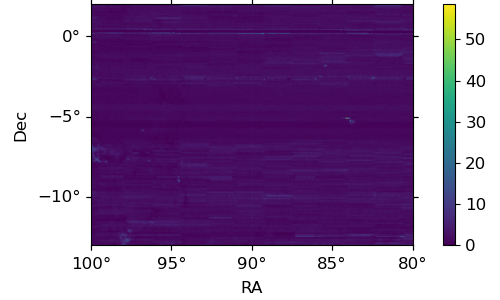

In [36]:
def displayimage(cube, region=None):
    img = cube.moment(order=0)  # moment 0
    fig, ax = plt.subplots(
        figsize=(5, 3), layout="compressed", subplot_kw={"projection": cube.wcs.celestial}
    )
    norm = simple_norm(img.value, vmin=0, vmax=np.nanmax(img.value), stretch="linear")
    im = ax.imshow(img.value, norm=norm, cmap="viridis", origin="lower")
    lon = ax.coords[0]
    lat = ax.coords[1]
    lon.set_major_formatter("dd")
    lat.set_major_formatter("dd")
    lon.set_axislabel("RA")
    lat.set_axislabel("Dec")
    if region != None:
        region.plot(color="white")
    plt.colorbar(im)
    plt.show()

displayimage(cube)

  0%|          | 0/21 [00:00<?, ?it/s]

Best value of s 2.2
N(True) / N(total) 0.0192


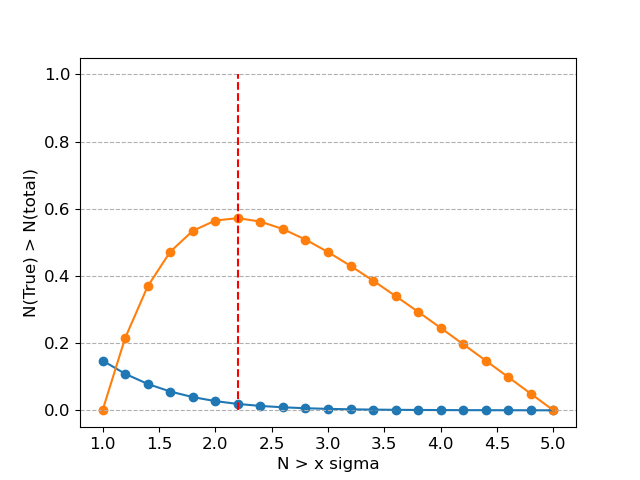

In [37]:
# sigma clipping data to select value N > sσ

def test_sigma_clip(test=False):
    if test == True:
        # use knee/elbow value to find the best s value
        s_ = np.arange(1, 5.2, 0.2)
        y_ = []

        for i in trange(len(s_)):
            upper_bound = MEDIAN + STD * s_[i]
            mask = (data > upper_bound)  # mask == True: N > sσ
            y_.append(np.count_nonzero(mask) / data.size)  # N(True) / N(total)

        kneedle = KneeLocator(s_, y_, S=1.0, curve="convex", direction="decreasing")  # knee/elbow value
        print("Best value of s", round(kneedle.elbow, 4))
        print("N(True) / N(total)", round(kneedle.elbow_y, 4))

        # plot the results
        fig = plt.figure()
        plt.scatter(s_, y_)
        plt.scatter(s_, kneedle.y_difference)
        plt.plot(s_, y_)
        plt.plot(s_, kneedle.y_difference)
        plt.ylim(-0.05, 1.05)
        plt.vlines(round(kneedle.elbow, 3), 0, 1, ls="--", colors="red")
        plt.xlabel("N > x sigma")
        plt.ylabel("N(True) > N(total)")
        plt.grid(axis="y", ls="--")
        plt.show()
        return kneedle.elbow
    else:
        # if (usually) the s value found this way is too small, choose s = 3
        return 3


s = test_sigma_clip(test=True)

In [38]:
upper_bound = MEDIAN + STD * s
mask = data > upper_bound

# index is a 2D array, where each row is [v, y, x] coordinate for a point with value N > sσ
# this will be used for clustering
index = np.argwhere(mask)
print(f"Number of points with value N > sσ: {len(index)}")
print(f"Percentage of points with value N > sσ: {len(index)/data.size*100:.2f}%")

Number of points with value N > sσ: 9166097
Percentage of points with value N > sσ: 1.92%


### 记录表

eps = 1, sqrt(2), sqrt(3)

min_samples = 2, 4, 6,  
              6, 9, 12, 15, 18,  
              9, 12, 15, 18

**记录每一个(eps, min_samples)参数组下，表现最好的SNR/spatial_pixels/FWHM**

N为HVC candidate数目，F为其中的假信号数目，T为其中的真信号数目

| eps | minPts | | SNR | SIZE(arcmin) | FWHM(km/s) | | N | F | T |
| - | - | - | - | - | - | - | - | - | - |
| 3 | 18 |   | 4 | 4 | 4 |   | 13 | 1 | 12 |
| 3 | 15 |   | 4 | 4 | 3.5 |   | 14 | 1 | 12 |
| 3 | 12 |   | 4 | 4 | 3.5 |   | 15 | 2 | 13 |
| 3 | 9 |    | 3.5 | 4 | 3.5 |   | 14 | 2 | 12 |
| 3 | 6 |    | 4 | 4 | 4 |   | 12 | 2 | 10 |
|   |   |    |   |   |   |   |    |   |    |
| 2 | 18 |   | 4 | 4 | 4 |   | 13 | 1 | 12 |
| 2 | 15 |   | 4 | 4 | 3.5 |   | 14 | 1 | 13 |
| 2 | 12 |   | 4 | 4 | 3.5 |   | 15 | 2 | 13 |
| 2 | 9 |    | 4 | 4 | 4 |   | 12 | 2 | 10 |
| 2 | 6 |    | 4 | 4 | 4 |   | 12 | 2 | 10 |
|   |   |    |   |   |   |   |    |   |    |
| 1 | 6 |    | 4 | 4 | 4 |   | 11 | 1 | 10 |
| 1 | 4 |    | 4 | 4 | 5 |   | 10 | 1 | 9 |
| 1 | 2 |    | 4 | 4 | 4 |   | 10 | 1 | 9 |

备注：eps=3，minPts=9时，(131,70)有一个新的候选体，其余参数下并未见到，可能是被淹没于背景

In [39]:
# Set the parameters for DBSCAN: eps, minPts

eps = np.sqrt(3)
minPts = 12

In [40]:
# DBSCAN clustering

db = DBSCAN(eps=eps, min_samples=minPts, n_jobs=-1).fit(index)  # DBSCAN clustering
# db.labels_ is an array of the same length as index, where each element is the cluster label for that point.
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
unique_labels = set(labels)
n_clusters = len(unique_labels) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters)
print("Estimated number of noise points: %d" % n_noise)

Estimated number of clusters: 21053
Estimated number of noise points: 8601715


In [41]:
# Calculate moment 0 using pure Python (faster for smaller clusters)
def moment_0_py(data, vyx):
    # vyx is coordinates [v, y, x] of points in the cluster (labels == cluster_id)
    # Extract the velocity column and the coordinate column separately
    velo = vyx[:, 0]  # velocity [v]
    coords = vyx[:, 1:]  # coordinates [y, x]
    # Find unique rows in the x,y columns and their indices
    unique_coords, indices = np.unique(coords, axis=0, return_inverse=True)
    # unique_coords is a 2D array of unique [y, x] coordinates
    # indices is an array of the same length as coords, where each element is the index of the unique coordinate
    # This means that for each coordinate in coords, we can find several velocities in velo that correspond to it.

    # Calculate moment 0 of the velocity axis
    # for each unique pair of the coordinates
    def calc_moment_0(unique_coords, indices, velo, data):
        moment_0 = np.zeros(len(unique_coords))
        for i in range(len(unique_coords)):  # for each unique coordinate
            # Calculate the moment 0 for this coordinate
            # M0 = \int I_v dv = \sum I_v * delta_v
            m0 = 0
            coo = unique_coords[i]
            for v in velo[indices == i]:  # sum over all velocities that correspond to this coordinate
                m0 += data[v, coo[0], coo[1]] * abs(delta_v)  # moment 0
            moment_0[i] = m0
        return moment_0
    moment_0 = calc_moment_0(unique_coords, indices, velo, data)
    # Combine the unique coordinates with their moment 0
    # wrap the result in a sparse matrix (COO format)
    # this is more memory efficient for large datasets
    moment_0_coo = sp.coo_array(
        (moment_0, (unique_coords[:, 0], unique_coords[:, 1])), shape=data[0].shape
    )
    return moment_0_coo


# Calculate moment 0 using pure Spectral-Cube (faster for larger clusters)
# https://github.com/radio-astro-tools/spectral-cube/blob/e98b6c3c05e3a21c6ca62524e1dea9582ad5cd38/spectral_cube/_moments.py#L170
def moment_0_sc(data, vyx):
    # create a cube which only contains the values of points in the cluster (labels == cluster_id)
    bool_array = np.zeros(data.shape, dtype=np.bool)
    bool_array[vyx[:, 0], vyx[:, 1], vyx[:, 2]] = (
        True  # mark all points in the cluster (labels == cluster_id) as True
    )
    cluster_data = bool_array * data  # multiply the data with the boolean array to get only the values of points in the cluster
    bool_cube = sc(cluster_data, wcs=wcs).with_spectral_unit(u.km / u.s)
    # Calculate moment 0 of the velocity axis
    moment_0 = bool_cube.moment(order=0).value
    # wrap the result in a sparse matrix (COO format)
    # this is more memory efficient for large datasets
    moment_0_coo = sp.coo_array(moment_0)
    return moment_0_coo


def moment_0_func(data, index, labels, n_clusters):
    # Optimized moment_0_func with parallel processing for faster computation.
    def compute_moment_0_for_cluster(cluster_id):
        vyx = index[labels == cluster_id]  # Get all coordinates [v, y, x] of points in the cluster (labels == cluster_id)
        size = len(vyx)
        if size < 100000:
            return moment_0_py(data, vyx)  # Use Python implementation for smaller clusters
        else:
            return moment_0_sc(data, vyx)  # Use spectral-cube for larger clusters

    # Use parallel processing to compute moment 0 for each cluster
    moment_0_results = Parallel(n_jobs=-1, backend="threading")(delayed(compute_moment_0_for_cluster)(cluster_id) for cluster_id in trange(n_clusters))

    # Combine results into a single array
    moment_0_cube = np.hstack(moment_0_results)
    return moment_0_cube

In [42]:
moment_0_cube = moment_0_func(data, index, labels, n_clusters)

  0%|          | 0/21053 [00:00<?, ?it/s]

In [43]:
# Calculate moment 1 using pure Python (faster for smaller clusters)
def moment_1_py(data, vyx):
    # vyx is coordinates [v, y, x] of points in the cluster (labels == cluster_id)
    # Extract the velocity column and the coordinate column separately
    velo = vyx[:, 0]  # velocity [v]
    coords = vyx[:, 1:]  # coordinates [y, x]
    # Find unique rows in the x,y columns and their indices
    unique_coords, indices = np.unique(coords, axis=0, return_inverse=True)
    # unique_coords is a 2D array of unique [y, x] coordinates
    # indices is an array of the same length as coords, where each element is the index of the unique coordinate
    # This means that for each coordinate in coords, we can find several velocities in velo that correspond to it.

    # Calculate moment 1 of the velocity axis
    # for each unique pair of the coordinates
    def calc_moment_1(unique_coords, indices, velo, data):
        moment_1 = np.zeros(len(unique_coords))
        for i in range(len(unique_coords)):  # for each unique coordinate
            # Calculate the moment 1 for this coordinate
            # M1 = \int v I_v dv / M0 = \sum I_v * v / \sum I_v
            m0 = 0
            m1 = 0
            coo = unique_coords[i]
            for v in velo[indices == i]:  # sum over all velocities that correspond to this coordinate
                m0 += data[v, coo[0], coo[1]]
                vel = velocities[v]
                m1 += data[v, coo[0], coo[1]] * vel  # moment 1
            moment_1[i] = m1 / m0
        return moment_1
    moment_1 = calc_moment_1(unique_coords, indices, velo, data)
    # Combine the unique coordinates with their moment 0
    # wrap the result in a sparse matrix (COO format)
    # this is more memory efficient for large datasets
    moment_1_coo = sp.coo_array(
        (moment_1, (unique_coords[:, 0], unique_coords[:, 1])), shape=data[0].shape
    )
    return moment_1_coo


# Calculate moment 0 using pure Spectral-Cube (faster for larger clusters)
# https://github.com/radio-astro-tools/spectral-cube/blob/e98b6c3c05e3a21c6ca62524e1dea9582ad5cd38/spectral_cube/_moments.py#L170
def moment_1_sc(data, vyx):
    # create a cube which only contains the values of points in the cluster (labels == cluster_id)
    bool_array = np.zeros(data.shape, dtype=np.bool)
    bool_array[vyx[:, 0], vyx[:, 1], vyx[:, 2]] = (
        True  # mark all points in the cluster (labels == cluster_id) as True
    )
    cluster_data = bool_array * data  # multiply the data with the boolean array to get only the values of points in the cluster
    bool_cube = sc(cluster_data, wcs=wcs).with_spectral_unit(u.km / u.s)
    # Calculate moment 1 of the velocity axis
    moment_1 = bool_cube.moment(order=1).value
    # wrap the result in a sparse matrix (COO format)
    # this is more memory efficient for large datasets
    moment_1_coo = sp.coo_array(moment_1)
    return moment_1_coo


def moment_1_func(data, index, labels, n_clusters):
    # Optimized moment_1_func with parallel processing for faster computation.
    def compute_moment_1_for_cluster(cluster_id):
        vyx = index[labels == cluster_id]  # Get all coordinates [v, y, x] of points in the cluster (labels == cluster_id)
        size = len(vyx)
        if size < 100000:
            return moment_0_py(data, vyx)  # Use Python implementation for smaller clusters
        else:
            return moment_0_sc(data, vyx)  # Use spectral-cube for larger clusters

    # Use parallel processing to compute moment 1 for each cluster
    moment_1_results = Parallel(n_jobs=-1, backend="threading")(delayed(compute_moment_1_for_cluster)(cluster_id) for cluster_id in trange(n_clusters))

    # Combine results into a single array
    moment_1_cube = np.hstack(moment_1_results)
    return moment_1_cube

In [44]:
moment_1_cube = moment_1_func(data, index, labels, n_clusters)

  0%|          | 0/21053 [00:00<?, ?it/s]

In [45]:
# Calculate moment 2 (FWHM) using pure Python (faster for smaller clusters)
def moment_2_py(data, vyx):
    # vyx is coordinates [v, y, x] of points in the cluster (labels == cluster_id)
    # Extract the velocity column and the coordinate column separately
    velo = vyx[:, 0]  # velocity [v]
    coords = vyx[:, 1:]  # coordinates [y, x]
    # Find unique rows in the x,y columns and their indices
    unique_coords, indices = np.unique(coords, axis=0, return_inverse=True)
    # unique_coords is a 2D array of unique [y, x] coordinates
    # indices is an array of the same length as coords, where each element is the index of the unique coordinate
    # This means that for each coordinate in coords, we can find several velocities in velo that correspond to it.

    # Calculate moment 2 of the velocity axis
    # for each unique pair of the coordinates
    def calc_moment_2(unique_coords, indices, velo, data):
        moment_2 = np.zeros(len(unique_coords))
        for i in range(len(unique_coords)):  # for each unique coordinate
            # Calculate the moment 1 for this coordinate
            # M2 = \int I_v (v - M1)^2 dv / M0 = \sum I_v * (v - M1)^2 / \sum I_v
            m0 = 0
            m1 = 0
            m2 = 0
            coo = unique_coords[i]
            # Calculate moment 0 and moment 1 for this coordinate
            for v in velo[indices == i]:  # sum over all velocities that correspond to this coordinate
                m0 += data[v, coo[0], coo[1]]
                vel = velocities[v]
                m1 += data[v, coo[0], coo[1]] * vel  # moment 1
            m1 = m1 / m0
            # Calculate moment 2 for this coordinate
            for v in velo[indices == i]:
                vel = velocities[v]
                m2 += data[v, coo[0], coo[1]] * ((vel - m1) ** 2)  # moment 2
            m2 = m2 / m0
            # Convert moment 2 to FWHM
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("error")
                    sigma = np.sqrt(m2)  # linewidth_sigma
            except RuntimeWarning as e:
                warnings.simplefilter("ignore", category=RuntimeWarning)
                sigma = np.sqrt(m2)  # linewidth_sigma, warning (m2 < 0)
            fwhm = sigma * np.sqrt(8 * np.log(2))  # FWHM = sqrt(8 * log(2)) * sigma
            if np.abs(m2) > delta_min:
                moment_2[i] = fwhm
            else:
                moment_2[i] = 0
        moment_2 = np.nan_to_num(moment_2)
        return moment_2
    moment_2 = calc_moment_2(unique_coords, indices, velo, data)
    # Combine the unique coordinates with their moment 0
    # wrap the result in a sparse matrix (COO format)
    # this is more memory efficient for large datasets
    moment_2_coo = sp.coo_array(
        (moment_2, (unique_coords[:, 0], unique_coords[:, 1])), shape=data[0].shape
    )
    moment_2_coo.eliminate_zeros()  # eliminate zeros to save memory
    return moment_2_coo


# Calculate moment 2 using pure Spectral-Cube (faster for larger clusters)
# https://github.com/radio-astro-tools/spectral-cube/blob/e98b6c3c05e3a21c6ca62524e1dea9582ad5cd38/spectral_cube/_moments.py#L170
def moment_2_sc(data, vyx):
    # create a cube which only contains the values of points in the cluster (labels == cluster_id)
    bool_array = np.zeros(data.shape, dtype=np.bool)
    bool_array[vyx[:, 0], vyx[:, 1], vyx[:, 2]] = (
        True  # mark all points in the cluster (labels == cluster_id) as True
    )
    cluster_data = bool_array * data  # multiply the data with the boolean array to get only the values of points in the cluster
    bool_cube = sc(cluster_data, wcs=wcs).with_spectral_unit(u.km / u.s)
    # Calculate moment 2 (FWHM) of the velocity axis
    moment_2 = bool_cube.linewidth_fwhm().value
    moment_2 = np.nan_to_num(moment_2)
    moment_2[np.abs(moment_2) < delta_min] = 0  # set small values to 0
    # wrap the result in a sparse matrix (COO format)
    # this is more memory efficient for large datasets
    moment_2_coo = sp.coo_array(moment_2)
    return moment_2_coo


def moment_2_func(data, index, labels, n_clusters):
    # Optimized moment_2_func with parallel processing for faster computation.
    def compute_moment_2_for_cluster(cluster_id):
        vyx = index[labels == cluster_id]  # Get all coordinates [v, y, x] of points in the cluster (labels == cluster_id)
        size = len(vyx)
        if size < 100000:
            return moment_2_py(data, vyx)  # Use Python implementation for smaller clusters
        else:
            return moment_2_sc(data, vyx)  # Use spectral-cube for larger clusters

    # Use parallel processing to compute moment 2 for each cluster
    moment_2_results = Parallel(n_jobs=-1, backend="threading")(delayed(compute_moment_2_for_cluster)(cluster_id) for cluster_id in trange(n_clusters))

    # Combine results into a single array
    moment_2_cube = np.hstack(moment_2_results)
    return moment_2_cube

In [46]:
moment_2_cube = moment_2_func(data, index, labels, n_clusters)

  0%|          | 0/21053 [00:00<?, ?it/s]

# 筛选符合要求的 HVC 候选体

SNR = 3, 4, 5

spatial_pixels = 4, 6, 9  # SIZE = 3.4, 4.2, 5.1 arcmin

FWHM = 3, 4, 5

In [61]:
# Select clusters based on the criteria
# Minimum SNR, SIZE, and FWHM
MIN_SNR = 3
MIN_SIZE = 4  # in pixels
MIN_FWHM = 3
MAX_FWHM = 1000

In [62]:
# Calculate condition SNR, SIZE, and FWHM for each cluster
def snr_size_fwhm(cluster_id, data, index, labels, MEDIAN, STD, moment_2_cube):
    # vyx is coordinates [v, y, x] of points in the cluster (labels == cluster_id)
    vyx = index[labels == cluster_id]
    cluster_value = data[vyx[:, 0], vyx[:, 1], vyx[:, 2]]
    # Calculate SNR
    peak = np.max(cluster_value)  # peak value in the cluster
    snr = (peak - MEDIAN) / STD  # signal-to-noise ratio (SNR) of the cluster
    # Calculate SIZE (spatial pixels)
    coords = vyx[:, 1:]  # coordinates [y, x]
    unique_yx = np.unique(coords, axis=0)  # unique [y, x] coordinates in the cluster
    # calculate the size of the cluster based on the number of spatial pixels
    size = len(unique_yx)
    # Get FWHM from moment_2_cube
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("error")
            fwhm = np.nanmean(moment_2_cube[cluster_id].data)
    except RuntimeWarning as e:
        warnings.simplefilter("ignore", category=RuntimeWarning)
        fwhm = np.nanmean(moment_2_cube[cluster_id].data)  # fwhm, warning (m2 < 0)
    snr_size_fwhm_arr = np.array([snr, size, fwhm])
    snr_size_fwhm_arr = np.nan_to_num(snr_size_fwhm_arr)  # replace NaN with 0
    return snr_size_fwhm_arr

# Find HVC candidates based on SNR, SIZE, and FWHM
def find_hvc_candidates(data, index, labels, n_clusters, MEDIAN, STD, moment_2_cube, MIN_SNR, MIN_SIZE, MIN_FWHM):
    # calculate condition SNR, SIZE, and FWHM for each cluster in parallel
    snr_size_fwhm_arr = Parallel(n_jobs=-1, backend="threading")(
        delayed(snr_size_fwhm)(cluster_id, data, index, labels, MEDIAN, STD, moment_2_cube)
        for cluster_id in trange(n_clusters)
    )
    snr_size_fwhm_arr = np.array(snr_size_fwhm_arr) # convert list to numpy array
    # generate a boolean array based on the conditions
    # True is the index of HVC candidates
    TF = (
    (snr_size_fwhm_arr[:, 0] > MIN_SNR) &
    (snr_size_fwhm_arr[:, 1] > MIN_SIZE) &
    (snr_size_fwhm_arr[:, 2] > MIN_FWHM)
    ).astype(int)
    hvc_candidates = np.nonzero(TF)[0]  # get indices of HVC candidates
    # Create a 2D array with SNR, SIZE, and FWHM for each HVC candidate
    hvc_candidates_array = np.tile(TF, (3, 1)).T * snr_size_fwhm_arr
    SNR = hvc_candidates_array[hvc_candidates][:, 0]
    SIZE = hvc_candidates_array[hvc_candidates][:, 1]
    FWHM = hvc_candidates_array[hvc_candidates][:, 2]
    return hvc_candidates, SNR, SIZE, FWHM


hvc_candidates, SNR, SIZE, FWHM = find_hvc_candidates(data, index, labels, n_clusters, MEDIAN, STD, moment_2_cube, MIN_SNR, MIN_SIZE, MIN_FWHM)
hvc_candidates

  0%|          | 0/21053 [00:00<?, ?it/s]

array([17172, 17256, 17275, 19141, 19244, 19261, 19607, 20600])

In [63]:
# Number of HVC candidates
N_HVC = len(hvc_candidates)

### 计算HVC候选体的光谱，并和HI4PI相同区域的光谱对比

In [64]:
import numpy as np
from joblib import Parallel, delayed
from itertools import islice
import gc

def memory_efficient_calc_spectrum(cluster_id, data, index, labels, velocities, total=False):
    """内存优化的频谱计算函数"""
    vyx = index[labels == cluster_id]

    # 确定边界而不创建大型布尔数组
    if total:
        yx_unique = np.unique(vyx[:, 1:], axis=0)
        min_y, max_y = yx_unique[:, 0].min(), yx_unique[:, 0].max()
        min_x, max_x = yx_unique[:, 1].min(), yx_unique[:, 1].max()
        sub_data = data[:, min_y:max_y+1, min_x:max_x+1]
        vel_array = velocities
    else:
        v_unique = np.unique(vyx[:, 0])
        min_v, max_v = v_unique.min(), v_unique.max()
        yx_unique = np.unique(vyx[:, 1:], axis=0)
        min_y, max_y = yx_unique[:, 0].min(), yx_unique[:, 0].max()
        min_x, max_x = yx_unique[:, 1].min(), yx_unique[:, 1].max()
        sub_data = data[min_v:max_v+1, min_y:max_y+1, min_x:max_x+1]
        vel_array = velocities[min_v:max_v+1]

    # 内存高效处理
    with np.errstate(invalid='ignore'):
        mask = sub_data != 0
        valid_counts = np.sum(mask, axis=(1, 2))
        sums = np.sum(np.where(mask, sub_data, 0), axis=(1, 2))
        spectrum = np.divide(sums, valid_counts, out=np.zeros_like(sums), where=valid_counts!=0)

    return vel_array, spectrum

def process_chunk(indices, data, hidpi_data, index, labels, velocities):
    """处理一个数据块"""
    chunk_results = []
    for i in indices:
        cluster_id = hvc_candidates[i]
        vel_cr, spectrum_cr = memory_efficient_calc_spectrum(cluster_id, data, index, labels, velocities, False)
        vel_cr_total, spectrum_cr_total = memory_efficient_calc_spectrum(cluster_id, data, index, labels, velocities, True)
        vel_hi, spectrum_hi = memory_efficient_calc_spectrum(cluster_id, hidpi_data, index, labels, velocities, True)
        chunk_results.append((vel_cr, spectrum_cr, vel_cr_total, spectrum_cr_total, vel_hi, spectrum_hi))
        gc.collect()  # 处理完一个后立即回收内存
    return chunk_results

# 主处理流程
chunk_size = 8  # 根据内存调整块大小
all_results = []

for chunk_start in range(0, N_HVC, chunk_size):
    chunk_indices = range(chunk_start, min(chunk_start + chunk_size, N_HVC))
    chunk_result = Parallel(n_jobs=-1, backend="threading")(
        delayed(process_chunk)([i], data, hidpi_data, index, labels, velocities)
        for i in chunk_indices
    )
    all_results.extend([item for sublist in chunk_result for item in sublist])
    gc.collect()  # 处理完一个块后回收内存

# 解压最终结果
vel_array_crafts, spectrum_crafts, vel_array_crafts_total, spectrum_crafts_total, vel_array_hi4pi, spectrum_hi4pi = zip(*all_results)

### 使用高斯滤波和峰值寻找，根据峰值高度和对称性自动判断光谱信号的真实性

In [65]:
def spec_find_peak(
    x,
    y_filtered,
    height=None,
    threshold=None,
    distance=None,
    prominence=None,
    width=None,
    wlen=None,
    rel_height=0.5,
    plateau_size=None,
):
    # Use scipy to find all the peaks in the filter response
    peaks, properties = find_peaks(
        y_filtered,
        height=height,
        threshold=threshold,
        distance=distance,
        prominence=prominence,
        width=width,
        wlen=wlen,
        rel_height=rel_height,
        plateau_size=plateau_size,
    )
    # Capture the prominence of each peak (how much does the peak stick up)
    prominences, left_bases, right_bases = peak_prominences(y_filtered, peaks)
    # Find the maximum prominence (which hopefully matches our signal)
    max_prom_index = np.argmax(prominences)
    peak_prominence = prominences[max_prom_index]
    # Find the x-value that the peak occurred at
    main_peak_x = x[peaks[max_prom_index]]
    main_peak_y = y_filtered[peaks[max_prom_index]]
    # the left base of the peak
    main_lbase_x = x[left_bases[max_prom_index]]
    main_lbase_y = y_filtered[left_bases[max_prom_index]]
    # the right base of the peak
    main_rbase_x = x[right_bases[max_prom_index]]
    main_rbase_y = y_filtered[right_bases[max_prom_index]]
    main_peak_plot = [
        main_peak_x,
        main_peak_y,
        main_lbase_x,
        main_lbase_y,
        main_rbase_x,
        main_rbase_y,
    ]
    # Calculate the skew (a measure of asymmetry) of the peak
    # left base: L, right base: R, peak position: P
    # skew = |L + R - 2P| / |L - R|
    skew = np.abs(main_peak_plot[2] + main_peak_plot[4] - 2 * main_peak_plot[0])
    skew /= np.abs(main_peak_plot[2] - main_peak_plot[4])
    return main_peak_x, peak_prominence, main_peak_plot, skew

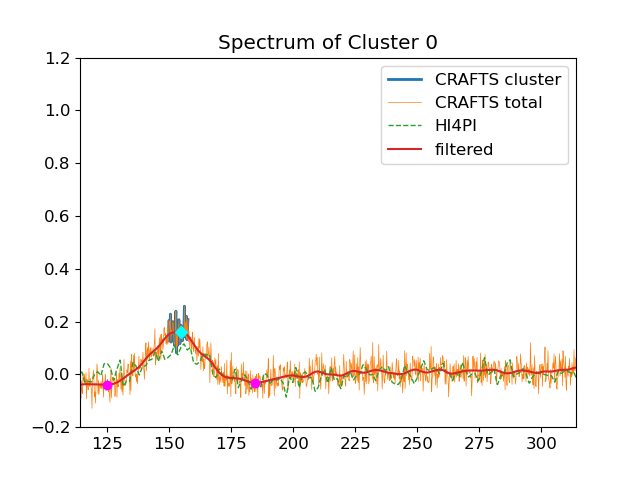

True signal
Cluster: 0, v_peak: 154.715 km/s, peak_prominence: 0.193, skew: 0.003


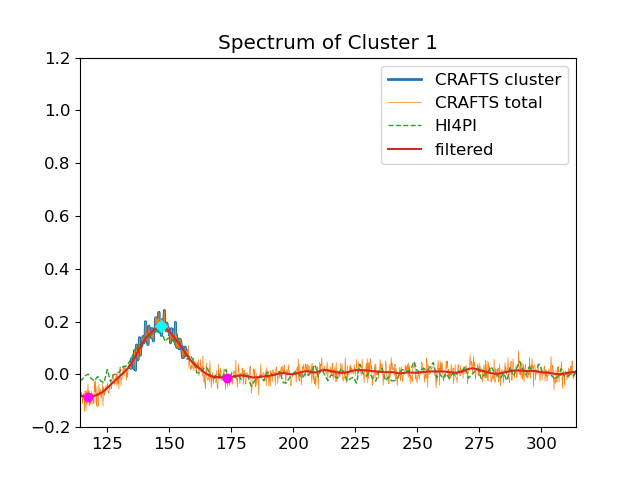

True signal
Cluster: 1, v_peak: 146.664 km/s, peak_prominence: 0.195, skew: 0.047


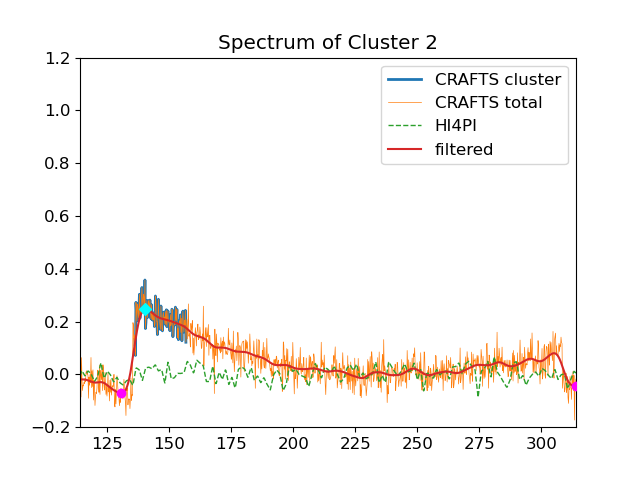

False signal
Cluster: 2, v_peak: 140.424 km/s, peak_prominence: 0.294, skew: 0.892


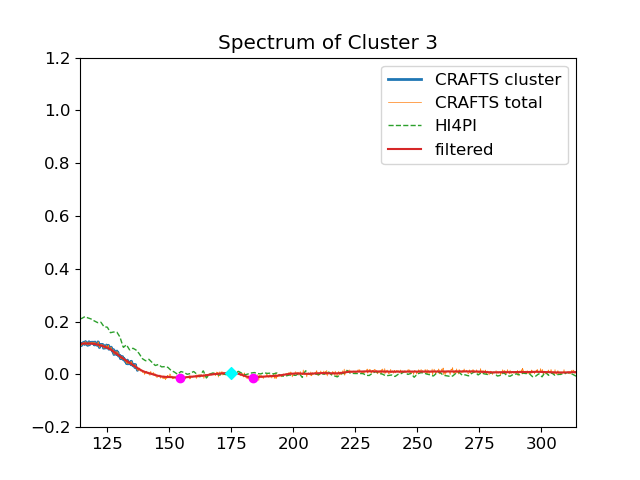

False signal
Cluster: 3, v_peak: 174.843 km/s, peak_prominence: 0.018, skew: 0.393


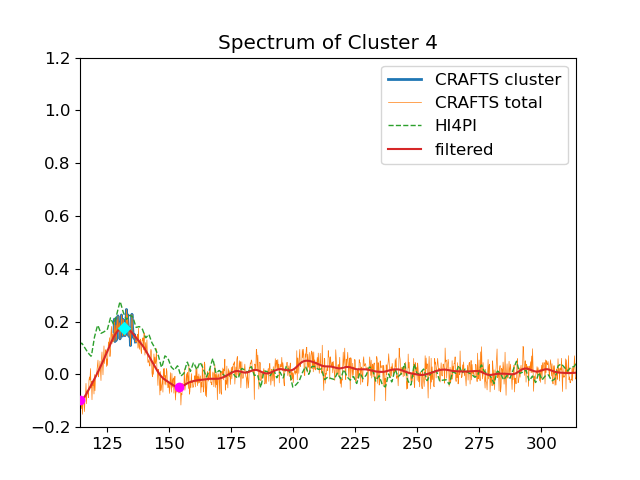

True signal
Cluster: 4, v_peak: 131.769 km/s, peak_prominence: 0.226, skew: 0.111


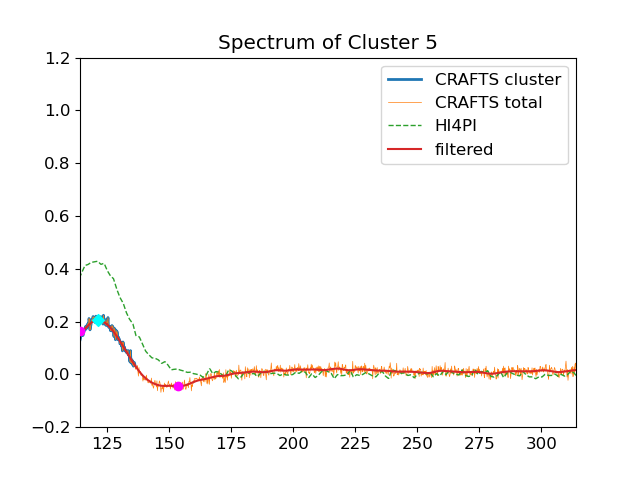

False signal
Cluster: 5, v_peak: 121.302 km/s, peak_prominence: 0.044, skew: 0.635


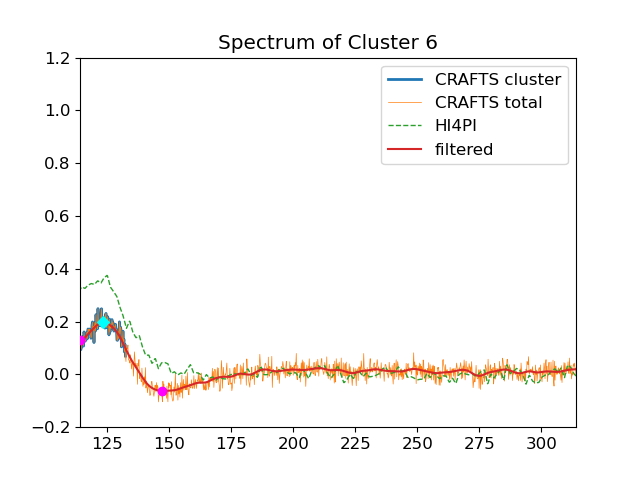

False signal
Cluster: 6, v_peak: 123.315 km/s, peak_prominence: 0.067, skew: 0.442


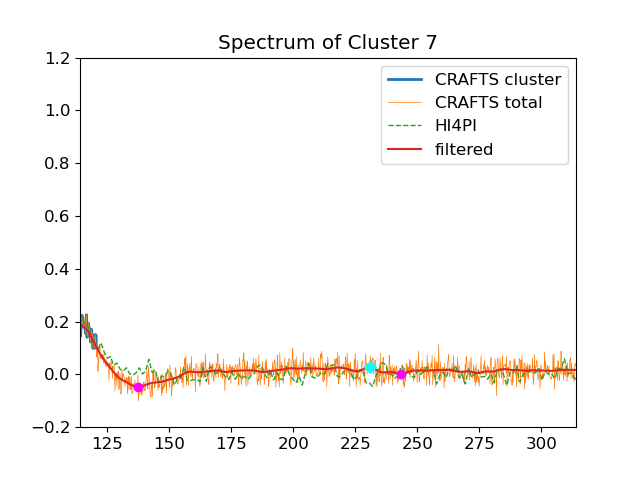

False signal
Cluster: 7, v_peak: 230.800 km/s, peak_prominence: 0.026, skew: 0.760
N_HVC = 8, F_HVC = 5, T_HVC = 3


In [66]:
F_HVC = 0
hvc_candidates_filter = np.zeros_like(hvc_candidates, dtype=bool)

for i in range(N_HVC):
    y_filtered = gaussian_filter(spectrum_crafts_total[i], sigma=10)
    v_max = np.where(vel_array_crafts_total[i] == vel_array_crafts[i][0])[0][0]
    v_min = np.where(vel_array_crafts_total[i] == vel_array_crafts[i][-1])[0][0]
    y_filtered_sub = y_filtered[v_max:v_min+1]
    v_peak, peak_prominence, main_peak_plot, skew = spec_find_peak(
        vel_array_crafts_total[i], y_filtered, rel_height=0.5
    )
    fig = plt.figure()
    plt.plot(vel_array_crafts[i], spectrum_crafts[i], lw=2, label="CRAFTS cluster")
    plt.plot(vel_array_crafts_total[i], spectrum_crafts_total[i], label="CRAFTS total", lw=0.5)
    plt.plot(vel_array_hi4pi[i], spectrum_hi4pi[i], label="HI4PI", lw=1, ls="--")
    plt.plot(vel_array_crafts_total[i], y_filtered, label="filtered", lw=1.5)
    # plt.plot(vel_array_crafts[i], y_filtered_sub, label="filtered", lw=1.5)
    # plt.scatter(x[peaks], y_filtered[peaks], c="cyan", marker="+")
    plt.scatter(
        main_peak_plot[0],
        main_peak_plot[1],
        c="cyan",
        marker="D",
        zorder=100,
    )
    # plt.scatter(x[left_bases], y_filtered[left_bases], c="magenta", marker="+")
    plt.scatter(
        main_peak_plot[2],
        main_peak_plot[3],
        c="magenta",
        zorder=100,
    )
    # plt.scatter(x[right_bases], y_filtered[right_bases], c="magenta", marker="+")
    plt.scatter(
        main_peak_plot[4],
        main_peak_plot[5],
        c="magenta",
        zorder=100,
    )
    plt.legend()
    plt.xlim(np.min(velocities), np.max(velocities))
    plt.ylim(-0.2, 1.2)
    plt.title(f"Spectrum of Cluster {i}")
    plt.show()
    if peak_prominence > 0.1 and skew < 0.6:
        print("True signal")
        hvc_candidates_filter[i] = True
    else:
        print("False signal")
        F_HVC += 1
    print(
        f"Cluster: {i}, v_peak: {v_peak:.3f} km/s, peak_prominence: {peak_prominence:.3f}, skew: {skew:.3f}"
    )


T_HVC = N_HVC - F_HVC
print(f"N_HVC = {N_HVC}, F_HVC = {F_HVC}, T_HVC = {T_HVC}")

In [74]:
hvc_candidates_filter = np.zeros_like(hvc_candidates, dtype=bool)
true_indices = [0,1,3,4,5,6,7]
hvc_candidates_filter[true_indices] = True

In [75]:
hvc_candidates_filtered = hvc_candidates[hvc_candidates_filter]
hvc_candidates_filtered

array([17172, 17256, 19141, 19244, 19261, 19607, 20600])

In [76]:
def half_flux_ellipse(moment_0_crop):
    total_flux = np.sum(moment_0_crop)
    coords = [[y, x] for x in range(moment_0_crop.shape[0]) for y in range(moment_0_crop.shape[1])]
    values = moment_0_crop.flatten()
    # Sort the coordinates by their values in descending order
    idx_sorted = np.argsort(values)[::-1]
    flux_sum = 0
    included = []
    for idx in idx_sorted:
        # add the flux of pixels
        flux_sum += values[idx]
        included.append(coords[idx])
        if flux_sum >= total_flux * 0.5:  # Check if we have included at least half of the total flux
            break
    included = np.array(included)
    # Fit an ellipse to the included points
    if included.shape[0] < 5:
        xc, yc, a, b, theta = 0, 0, 0, 0, 0
    else:
        ell = EllipseModel()
        ell.estimate(included)
        xc, yc, a, b, theta = ell.params
        theta = np.degrees(theta)  # Convert theta from radians to degrees
    return xc, yc, a, b, theta

# Calculate the size of the cluster based on the moment 0 cube
def calc_size(cluster_id, moment_0_cube):
    # Get the moment 0 array from the sparse matrix
    moment_0 = moment_0_cube[cluster_id].toarray()
    # Find the non-zero indices in the moment 0 cube
    nonzero_indices = np.nonzero(moment_0)
    y_min, y_max = np.min(nonzero_indices[0]), np.max(nonzero_indices[0])
    x_min, x_max = np.min(nonzero_indices[1]), np.max(nonzero_indices[1])
    moment_0_crop = moment_0[y_min:y_max+1, x_min:x_max+1]
    height, width = moment_0_crop.shape
    # Calculate the extent of the cropped moment 0 array
    # [x_min, x_max, y_max, y_min] because origin="lower"
    extent = [wcs.celestial.pixel_to_world_values(x_max, 0)[0],
            wcs.celestial.pixel_to_world_values(x_min, 0)[0],
            wcs.celestial.pixel_to_world_values(0, y_min)[1],
            wcs.celestial.pixel_to_world_values(0, y_max)[1]]
    x_min, x_max, y_min, y_max = extent  # now extent is in world coordinates
    xc, yc, a, b, theta = half_flux_ellipse(moment_0_crop)
    x_scale = (x_max - x_min) / (width - 1)  # pixel-to-world scale factor, here 0.025
    y_scale = (y_max - y_min) / (height - 1)  # pixel-to-world scale factor, here 0.025
    xc = x_min + (xc * x_scale)
    yc = y_min + (yc * y_scale)
    a = 2 * a * x_scale  # a is the major axis in degrees
    b = 2 * b * y_scale  # b is the minor axis in degrees
    size_arcmin = np.sqrt(a * b) * 60  # size is the average diameter of the ellipse in arcmin
    return moment_0_crop, extent, xc, yc, a, b, theta, size_arcmin

  0%|          | 0/7 [00:00<?, ?it/s]

Cluster 17172: size (arcmin)=4.75


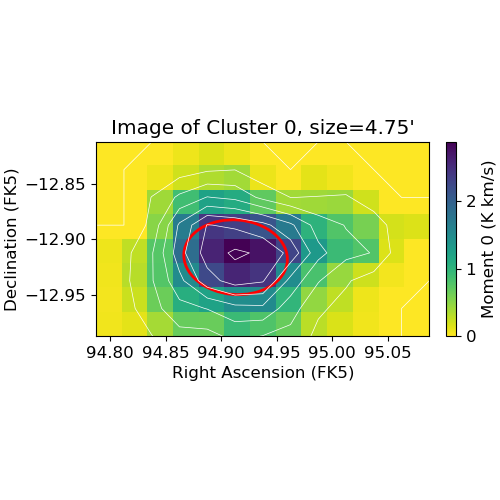

Cluster 17256: size (arcmin)=8.55


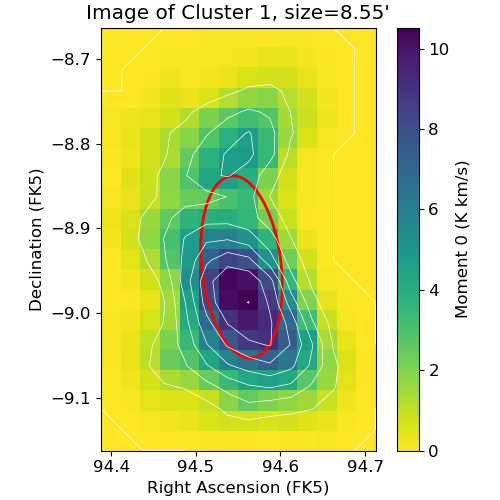

Cluster 19141: size (arcmin)=45.57


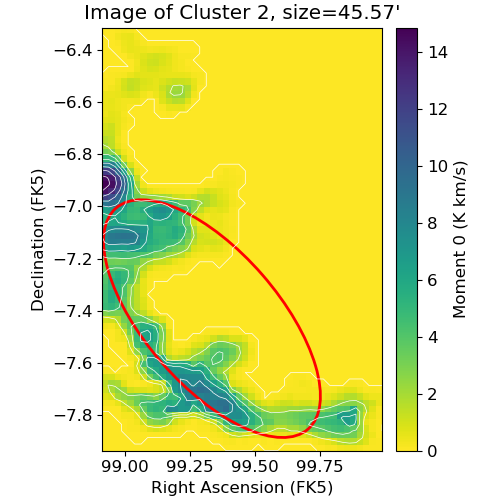

Cluster 19244: size (arcmin)=4.29


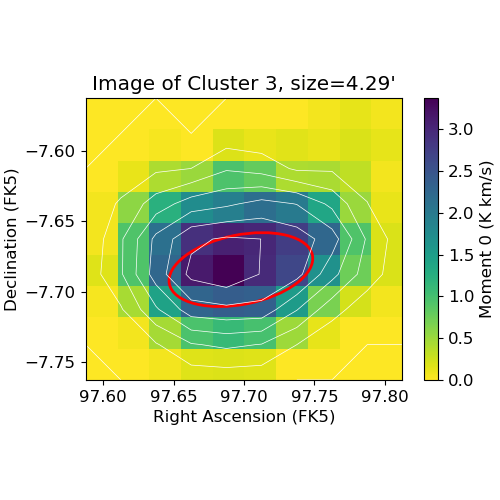

Cluster 19261: size (arcmin)=27.46


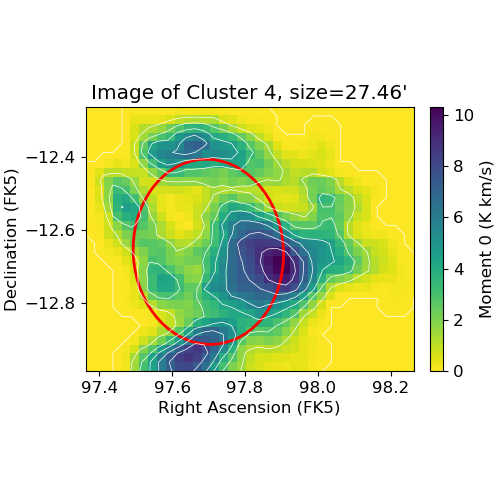

Cluster 19607: size (arcmin)=6.57


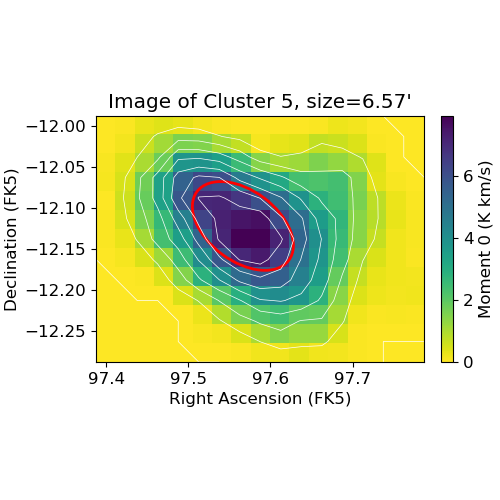

Cluster 20600: size (arcmin)=5.33


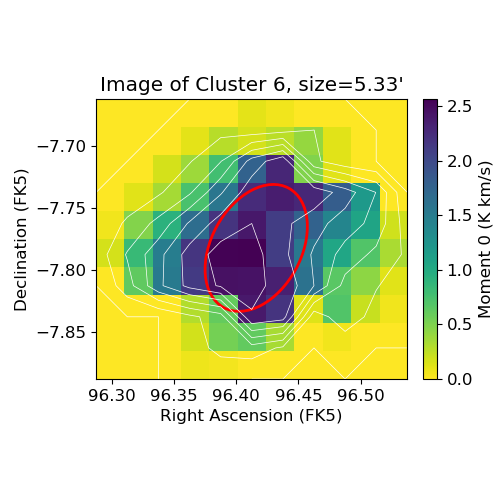

In [77]:
a_b_size = []
ellipses_params = []

for i in trange(len(hvc_candidates_filtered)):
    cluster_id = hvc_candidates_filtered[i]
    # Calculate the half-flux size for the cluster
    try:
        moment_0_crop, extent, xc, yc, a, b, theta, size_arcmin = calc_size(cluster_id, moment_0_cube)
    except TypeError as e:
        print(f"Cluster {i} failed for ellipse fitting: {e}")
        continue
    a_b_size.append((a, b, size_arcmin))
    ellipses_params.append((xc, yc, a, b, theta))
    print(f"Cluster {cluster_id}: size (arcmin)={size_arcmin:.2f}")
    fig, ax = plt.subplots(figsize=(5, 5), layout="compressed")
    im = ax.imshow(
        moment_0_crop,
        extent=extent,
        origin="lower",
        cmap="viridis_r",
        interpolation='none'
    )
    cs = ax.contour(moment_0_crop, extent=extent, colors='white', linewidths=0.5, linestyles='solid')
    ellipse = Ellipse((xc, yc), width=a, height=b, angle=theta, edgecolor='red', facecolor='none', lw=2)
    ax.add_patch(ellipse)
    plt.title(f"Image of Cluster {i}, size={size_arcmin:.2f}'")
    plt.xlabel("Right Ascension (FK5)")
    plt.ylabel("Declination (FK5)")
    plt.colorbar(im, label="Moment 0 (K km/s)")
    plt.show()

a_b_size = np.array(a_b_size)
ellipses_params = np.array(ellipses_params)

In [78]:
XCEN = []
YCEN = []
XPEAK = []
YPEAK = []
GLON = []
GLAT = []
RA = []
DEC = []
VLSR = []
TPKB = []
N_HI = []

for cluster_id in hvc_candidates_filtered:
    # vyx is coordinates [v, y, x] of points in the cluster (labels == cluster_id)
    vyx = index[labels == cluster_id]
    bool_array = np.zeros(data.shape, dtype=np.bool_)
    bool_array[vyx[:, 0], vyx[:, 1], vyx[:, 2]] = True
    cluster_data = bool_array * data
    center_vyx = np.mean(vyx, axis=0)
    peak_vyx = np.unravel_index(np.argmax(cluster_data), cluster_data.shape)
    peak_coord = wcs.pixel_to_world_values(peak_vyx[2], peak_vyx[1], peak_vyx[0])
    c_eq = SkyCoord(peak_coord[0], peak_coord[1], frame="fk5", unit="deg")
    c_gal = c_eq.galactic
    n_hi_peak = np.max(moment_0_cube[cluster_id]) * 1.823  # MNRAS 432, 3074–3079 (2013)
    XCEN.append(center_vyx[2])
    YCEN.append(center_vyx[1])
    XPEAK.append(peak_vyx[2])
    YPEAK.append(peak_vyx[1])
    RA.append(c_eq.ra.value)
    DEC.append(c_eq.dec.value)
    GLON.append(c_gal.l.value)
    GLAT.append(c_gal.b.value)
    VLSR.append(peak_coord[2] / 1000)
    TPKB.append(cluster_data[peak_vyx])
    N_HI.append(n_hi_peak)

XCEN = np.array(XCEN)
YCEN = np.array(YCEN)
XPEAK = np.round(XPEAK) + 1
YPEAK = np.array(YPEAK) + 1
RA = np.array(RA)
DEC = np.array(DEC)
GLON = np.array(GLON)
GLAT = np.array(GLAT)
VLSR = np.array(VLSR)
VGSR = VLSR + 220 * np.sin(GLON) * np.cos(GLAT)
TPKB = np.array(TPKB)
N_HI = np.array(N_HI)
if a_b_size.size == 0:
    SIZE_filtered = np.array([])
else:
    SIZE_filtered = a_b_size[:, 2]
SNR_filtered = SNR[hvc_candidates_filter]
FWHM_filtered = FWHM[hvc_candidates_filter]

In [79]:
# SNR, SIZE, FWHM, GLON, GLAT, RA, DEC, VLSR, VGSR, TPKB, N_HI

CATALOG = pd.DataFrame(
    {
        "ID": hvc_candidates_filtered,
        "XPEAK (pix)": XPEAK,
        "YPEAK (pix)": YPEAK,
        "RA (deg)": RA,
        "DEC (deg)": DEC,
        "GLON (deg)": GLON,
        "GLAT (deg)": GLAT,
        "SIZE (')": SIZE_filtered,
        "VLSR (km/s)": VLSR,
        "VGSR (km/s)": VGSR,
        "TPKB (K)": TPKB,
        "SNR": SNR_filtered,
        "FWHM (km/s)": FWHM_filtered,
        "N_HI (1e18 cm^-2)": N_HI,
    }
)
CATALOG = CATALOG.round(2)
CATALOG.to_csv(catalog_file, index=False)

# CATALOG = CATALOG.sort_values("GLON")
CATALOG

,ID,XPEAK (pix),YPEAK (pix),RA (deg),DEC (deg),GLON (deg),GLAT (deg),SIZE ('),VLSR (km/s),VGSR (km/s),TPKB (K),SNR,FWHM (km/s),N_HI (1e18 cm^-2)
0,17172,203,4,94.94,-12.91,221.04,-12.79,4.75,150.49,344.62,0.67,6.23,4.60,5.24
1,17256,219,160,94.54,-9.01,217.28,-11.46,8.55,143.04,95.45,1.06,9.79,7.45,19.19
2,19141,16,214,99.61,-7.66,218.31,-6.36,45.57,114.06,-105.18,1.10,10.23,6.82,27.12
3,19244,92,213,97.71,-7.69,217.48,-8.05,4.29,130.56,159.18,0.67,6.22,4.27,6.15
4,19261,91,13,97.74,-12.69,222.04,-10.23,27.46,118.69,-10.27,1.13,10.47,8.06,18.79
5,19607,96,35,97.61,-12.14,221.48,-10.10,6.57,122.71,-48.40,0.79,7.33,8.32,14.44
6,20600,144,209,96.41,-7.79,216.99,-9.25,5.33,116.47,164.03,0.73,6.72,3.37,4.68


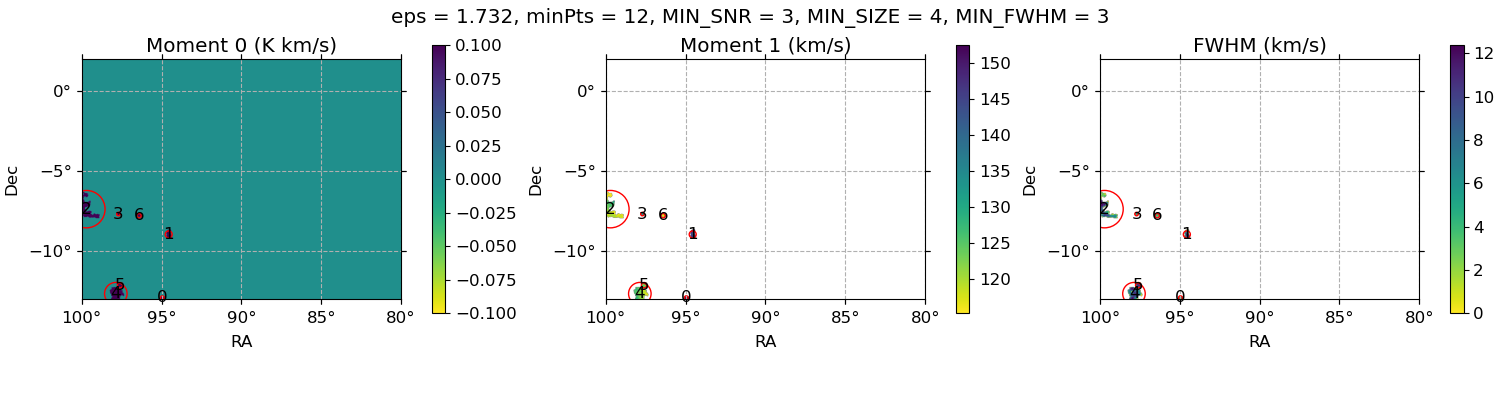

In [80]:
vyx_clusters = np.empty((0, 3))
for i in hvc_candidates_filtered:
    vyx = index[labels == i]  # 第i个cluster每个点的vyx坐标
    vyx_clusters = np.vstack((vyx_clusters, vyx))
vyx_clusters = vyx_clusters.astype(int)

bool_array = np.zeros(data.shape, dtype=np.bool_)
bool_array[vyx_clusters[:, 0], vyx_clusters[:, 1], vyx_clusters[:, 2]] = (
    True  # 对第i个cluster的每个点标记为True
)
hvc_candidates_cube = sc(bool_array * data, wcs=wcs).with_spectral_unit(u.km / u.s)
# 如果把bool_array替换为mask，就会显示DBSCAN前的数据

size_pixels = np.pi * (SIZE_filtered / 1.5) ** 2 / 4

fig, ax = plt.subplots(
    1,
    3,
    figsize=[15, 4],
    sharex=True,
    sharey=True,
    layout="compressed",
    subplot_kw={"projection": wcs.celestial},
)

moment_0 = hvc_candidates_cube.moment(order=0)
norm = None if np.all(np.isnan(moment_0.value)) else simple_norm(moment_0.value, percent=95)
im0 = ax[0].imshow(
    moment_0.value, norm=norm, cmap="viridis_r", origin="lower"
)
ax[0].scatter(XCEN, YCEN, s=size_pixels, c="None", alpha=1, edgecolor="red", )
for i, txt in enumerate(hvc_candidates_filtered):
    ax[0].annotate(i, (XCEN[i], YCEN[i]), va="center", ha="center")
ax[0].grid(linestyle="--")
ax[0].set_title("Moment 0 (K km/s)")
ax[0].set_xlabel("RA")
ax[0].set_ylabel("DEC")
lon = ax[0].coords[0]
lat = ax[0].coords[1]
lon.set_major_formatter("dd")
lat.set_major_formatter("dd")
lon.set_axislabel("RA")
lat.set_axislabel("Dec")
plt.colorbar(im0)

moment_1 = hvc_candidates_cube.moment(order=1)
norm = None if np.all(np.isnan(moment_1.value)) else simple_norm(moment_1.value, percent=95)
im1 = ax[1].imshow(
    moment_1.value, norm=norm, cmap="viridis_r", origin="lower"
)
ax[1].scatter(XCEN, YCEN, s=size_pixels, c="None", alpha=1, edgecolor="red")
for i, txt in enumerate(hvc_candidates_filtered):
    ax[1].annotate(i, (XCEN[i], YCEN[i]), va="center", ha="center")
ax[1].grid(linestyle="--")
ax[1].set_title("Moment 1 (km/s)")
lon = ax[1].coords[0]
lat = ax[1].coords[1]
lon.set_major_formatter("dd")
lat.set_major_formatter("dd")
lon.set_axislabel("RA")
lat.set_axislabel("Dec")
plt.colorbar(im1)

moment_2 = hvc_candidates_cube.linewidth_fwhm()
norm = None if np.all(np.isnan(moment_2.value)) else simple_norm(moment_2.value, percent=95)
im2 = ax[2].imshow(
    moment_2.value, norm=norm, cmap="viridis_r", origin="lower"
)
ax[2].scatter(XCEN, YCEN, s=size_pixels, c="None", alpha=1, edgecolor="red")
for i, txt in enumerate(hvc_candidates_filtered):
    ax[2].annotate(i, (XCEN[i], YCEN[i]), va="center", ha="center")
ax[2].grid(linestyle="--")
ax[2].set_title("FWHM (km/s)")
lon = ax[2].coords[0]
lat = ax[2].coords[1]
lon.set_major_formatter("dd")
lat.set_major_formatter("dd")
lon.set_axislabel("RA")
lat.set_axislabel("Dec")
plt.colorbar(im2)

fig.suptitle(
    f"eps = {np.round(eps, 3)}, minPts = {minPts}, MIN_SNR = {MIN_SNR}, "
    f"MIN_SIZE = {MIN_SIZE}, MIN_FWHM = {MIN_FWHM}"
)
plt.show()

moment_0.write(
    output_file[0],
    overwrite=True,
)
moment_1.write(
    output_file[1],
    overwrite=True,
)
moment_2.write(
    output_file[2],
    overwrite=True,
)